In [1]:
# !pip install -q silero_vad

In [24]:
import torch
import torchaudio

# Thông số audio
sr = 16000         # sample rate (Hz)
duration = 5       # giây
num_samples = sr * duration

# Tạo waveform toàn 0 (silence)
waveform = torch.zeros(num_samples).unsqueeze(0)  # [1, T]

# Lưu thành file WAV
torchaudio.save("/home/nampv1/projects/asr/asr_ft/data/examples/silence.wav", waveform, sr)

print("Saved silence.wav (5s of silence).")


Saved silence.wav (5s of silence).


/home/nampv1/anaconda3/envs/asr/lib/python3.11/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


In [2]:
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps

In [7]:
import torch

# Download model
model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False
)

(get_speech_timestamps,
 save_audio,
 read_audio,
 VADIterator,
 collect_chunks) = utils


Using cache found in /home/nampv1/.cache/torch/hub/snakers4_silero-vad_master


In [8]:
import matplotlib.pyplot as plt
import numpy as np


In [32]:
min_speech_duration_ms = 250
speech_timestamps = get_speech_timestamps(
        wav,
        model,
        sampling_rate=sr,
        min_speech_duration_ms=min_speech_duration_ms
    )

speech_timestamps

[]

[]


/home/nampv1/anaconda3/envs/asr/lib/python3.11/site-packages/silero_vad/utils_vad.py:139: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  list_backends = torchaudio.list_audio_backends()
/home/nampv1/anaconda3/envs/asr/lib/python3.11/site-packages/silero_vad/utils_vad.py:150: UserWarning: torchaudio.sox_effects.sox_effects.apply_effects_file has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  wav, sr = torchaudio.sox_effects.apply

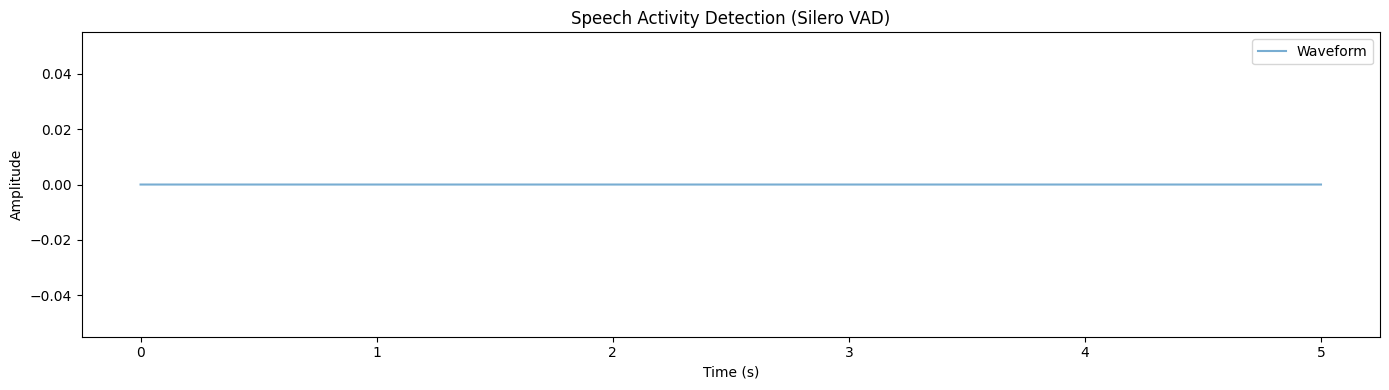

In [25]:
# read audio (must be mono 16 kHz wav or resampled)
# wav = read_audio('/home/nampv1/projects/asr/asr_ft/data/examples/example_vietbud500_02.wav')
# wav = read_audio('/home/nampv1/Downloads/1738232476.3986811.wav')
wav = read_audio('/home/nampv1/projects/asr/asr_ft/data/examples/silence.wav')

# get speech timestamps
speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=16000)

print(speech_timestamps)
# [{'start': 0, 'end': 32000}, {'start': 40000, 'end': 80000}, ...]


sampling_rate = 16000

# Convert waveform tensor to numpy for plotting
wav_np = wav.numpy()

# Time axis in seconds
time_axis = np.arange(len(wav_np)) / sampling_rate

# Plot waveform
plt.figure(figsize=(14, 4))
plt.plot(time_axis, wav_np, label="Waveform", alpha=0.6)

# Overlay speech regions
for seg in speech_timestamps:
    start = seg["start"] / sampling_rate
    end = seg["end"] / sampling_rate
    plt.axvspan(start, end, color="red", alpha=0.3)

plt.title("Speech Activity Detection (Silero VAD)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(["Waveform", "Detected speech"])
plt.tight_layout()
plt.show()


In [26]:
speech_wav = collect_chunks(speech_timestamps, wav)

RuntimeError: torch.cat(): expected a non-empty list of Tensors

In [27]:
len(wav)

80000

In [22]:
len(speech_wav)

629312

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(wav, sampling_rate=16000, title="Audio Waveform"):
    """
    wav: torch.Tensor or np.ndarray
    sampling_rate: int
    """
    if hasattr(wav, "numpy"):  # if torch.Tensor
        wav = wav.numpy()

    time_axis = np.arange(len(wav)) / sampling_rate

    plt.figure(figsize=(14, 4))
    plt.plot(time_axis, wav, label="Waveform", alpha=0.7, color="blue")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()


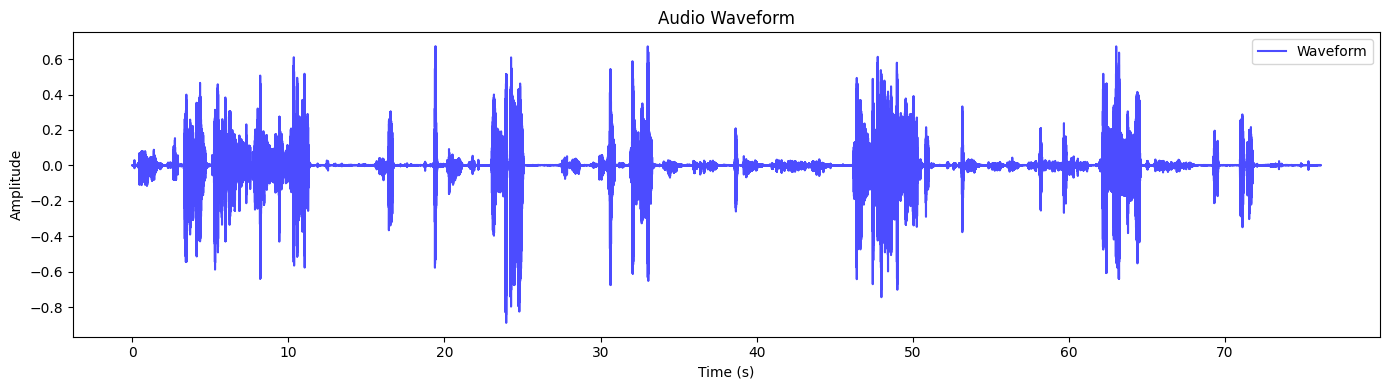

In [37]:
plot_waveform(wav)

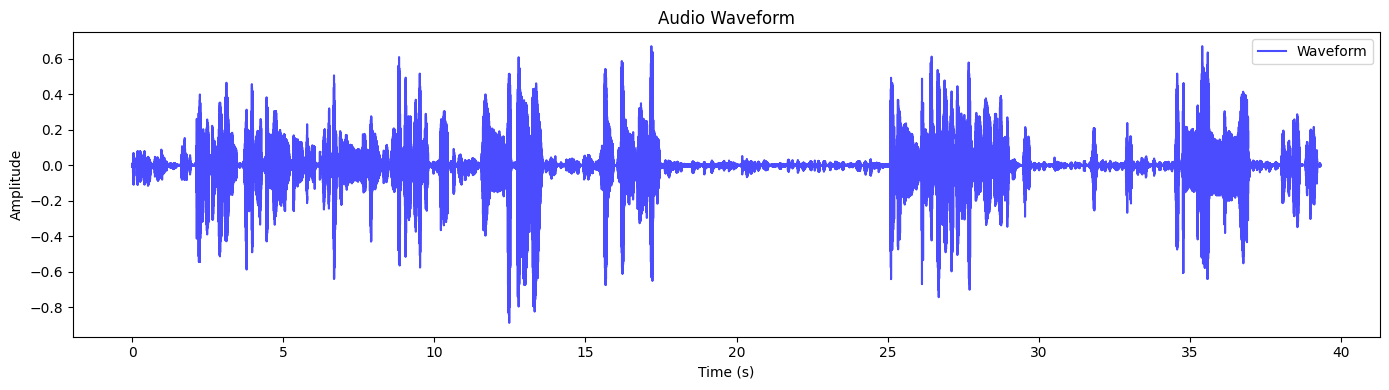

In [38]:
plot_waveform(speech_wav)

In [42]:
import torch
import torchaudio
import silero_vad
import websocket
import io
import soundfile as sf
import numpy as np

# --- Load Silero VAD model ---
# model, utils = silero_vad.load_vad_model()
# (get_speech_timestamps, _, read_audio, _, _) = utils

import torch

# Download model
model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False
)

(get_speech_timestamps,
 save_audio,
 read_audio,
 VADIterator,
 collect_chunks) = utils


# --- WebSocket connect ---
ws = websocket.WebSocket()
ws.connect("ws://localhost:8000/api/v1/asr/chunk")

# --- Load audio WAV ---
audio_path = "/home/nampv1/Downloads/1737530609.3746396.wav"
audio, sr = sf.read(audio_path)
# Silero VAD yêu cầu float32 mono
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)
audio = audio.astype(np.float32)

# --- Detect speech timestamps ---
speech_timestamps = get_speech_timestamps(torch.from_numpy(audio), model, sampling_rate=sr)

for ts in speech_timestamps:
    start, end = ts['start'], ts['end']
    start_time = start / sr
    end_time = end / sr
    chunk = audio[start:end]
    buf = io.BytesIO()
    sf.write(buf, chunk, sr, format="WAV")
    buf.seek(0)
    ws.send_binary(buf.read())
    msg = ws.recv()
    print(f"Partial transcript ({start_time:.3f}s - {end_time:.3f}s):", msg)


Using cache found in /home/nampv1/.cache/torch/hub/snakers4_silero-vad_master


Partial transcript (0.642s - 2.174s): {"partial":"ぷびなすばさわしね","duration":1.532}
Partial transcript (2.274s - 4.222s): {"partial":" Bà ơi bạn trách giúp mình cái bill gửi này với.","duration":1.948}
Partial transcript (4.418s - 5.022s): {"partial":" Thank you.","duration":0.604}
Partial transcript (6.882s - 7.326s): {"partial":" Gracias.","duration":0.444}
Partial transcript (7.778s - 8.926s): {"partial":" 3, 4, 4, 6.","duration":1.148}
Partial transcript (10.082s - 10.494s): {"partial":" terima kasih","duration":0.412}
Partial transcript (10.978s - 12.190s): {"partial":" Ông 1459.","duration":1.212}
Partial transcript (12.674s - 13.022s): {"partial":" Vão.","duration":0.348}
Partial transcript (13.378s - 13.918s): {"partial":" Benão.","duration":0.54}
Partial transcript (14.242s - 15.966s): {"partial":" Dạ vâng, chị mới làm sụp em một chút giúp em ạ","duration":1.724}
Partial transcript (27.810s - 30.942s): {"partial":" Cảm ơn chị đã xưa máy, đơn hàng chị đang phản ánh vấn đề thu gom đú

### Pyannote VAD

In [18]:
cd /home/nampv1/projects/asr/asr-deployment-app

/home/nampv1/projects/asr/asr-deployment-app


In [20]:
# !git clone https://github.com/alesaccoia/VoiceStreamAI

In [22]:
cd VoiceStreamAI

/home/nampv1/projects/asr/asr-deployment-app/VoiceStreamAI
